In [1]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler

# 1. Load the data (based on the attributes provided in the sources)
# The data includes metrics like npxG, passes, and duels [1]
df = pd.read_csv('./data/demo_data/football/Forwards.csv', encoding='latin-1')
# ADD: encoding

# 2. Select numerical features for analysis
features = [
    'final_third_passes_adjusted_per90', 'smart_passes_adjusted_per90', 
    'key_passes_adjusted_per90', 'air_duels_won_adjusted_per90',
    'ground_duels_won_adjusted_per90', 'final_third_receptions_adjusted_per90',
    'npxG_adjusted_per90'
]
x = df[features]

# 3. Standardize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 4. Perform Factor Analysis with 2 factors
# We use 'varimax' rotation to make the factors more interpretable
fa = FactorAnalyzer(n_factors=2, rotation="varimax")
fa.fit(x_scaled)

# 5. Get Factor Loadings
loadings = pd.DataFrame(
    fa.loadings_, 
    columns=['Factor 1: Creative Playmaking', 'Factor 2: Target Man'], 
    index=features
)

print("Factor Loadings:")
print(loadings)


# 6. Get Factor Scores for specific players mentioned in sources
# e.g., Hazard [3] vs Crouch [5]
scores = fa.transform(x_scaled)
df_scores = pd.DataFrame(scores, columns=['Creative_Score', 'Target_Man_Score'])
result = pd.concat([df['shortName'], df_scores], axis=1)

print("\nSample Player Scores:")
print(result[result['shortName'].isin(['Eden Hazard', 'Peter Crouch', 'Alexis Sánchez'])])

FileNotFoundError: [Errno 2] No such file or directory: './data/demo_data/football/Forwards.csv'

The data highlights a clear trade-off between these factors. For instance, Peter Crouch scores at the top of the Target Man dimension (29.43 air duels won) but has nearly zero involvement in the Creative dimension, with only 0.11 smart passes. Conversely, Mohamed Salah shows high goal-scoring and creative potential but almost no aerial presence (0.50 air duels won), illustrating the distinct separation between these two tactical profiles.
# Naming the column
1. Creative_Score: This column corresponds to Factor 1 (Creativity and Technical Involvement). It measures a player's ability to distribute the ball and create goal-scoring opportunities. This is exemplified in the sources by players like Eden Hazard, who records 49.59 final third passes and 2.64 smart passes per 90 minutes, and Alexis Sánchez, who averages 39.37 final third passes and 3.37 smart passes,.
2. Target_Man_Score: This column corresponds to Factor 2 (Physical and Aerial Dominance). It identifies the "target man" or pivot profile, characterized by a high frequency of winning aerial challenges. According to the sources, this style is best illustrated by Peter Crouch, who wins 29.43 aerial duels per 90 minutes, and Sam Vokes, who wins 23.96.
   

## Cluster Naming and Profiles
Using the data provided, the clusters are defined as follows:
• Cluster 1: Technical Creators
    ◦ Description: Players in this group specialize in ball progression and chance creation through high-volume passing.
    ◦ Key Stats: They record the highest values for final_third_passes_adjusted_per90 and smart_passes_adjusted_per90.
    ◦ Examples: Eden Hazard (49.59 final third passes), Alexis Sánchez (3.37 smart passes), and Philippe Coutinho (38.45 final third passes).
• Cluster 2: Aerial Target Men
    ◦ Description: This group is defined by physical presence, serving as an outlet for long balls and winning duels in the air.
    ◦ Key Stats: These players dominate the air_duels_won_adjusted_per90 metric but often have low creative passing stats.
    ◦ Examples: Peter Crouch (29.43 aerial duels won), Sam Vokes (23.96 aerial duels won), and Christian Benteke (22.83 aerial duels won).
• Cluster 3: Elite Goal Finishers
    ◦ Description: These players prioritize positioning and finishing, maintaining high efficiency in front of the net.
    ◦ Key Stats: High scores in npxG_adjusted_per90 and goals_adjusted_per90.
    ◦ Examples: Mohamed Salah (1.56 goals per 90), Harry Kane (1.02 npxG), and Sergio Agüero (1.08 goals per 90).

--------------------------------------------------------------------------------




C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.p

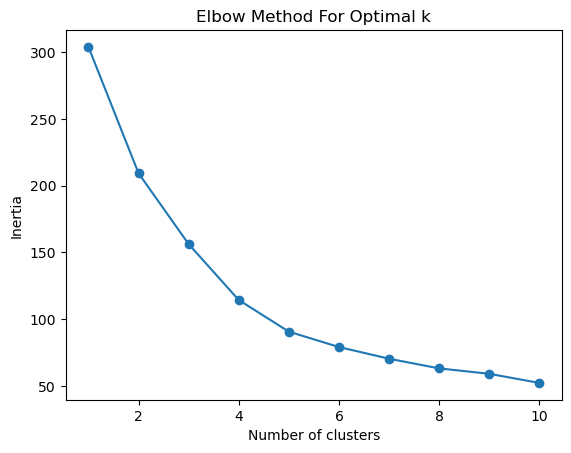

        shortName          Cluster_Name
61  Mohamed Salah  Elite Goal Finishers


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load data based on source metrics
x = pd.read_csv('./data/demo_data/football/Forwards.csv', encoding='latin-1')

# Selecting relevant features for tactical profiling
features = [
    'npxG_adjusted_per90', 
    'final_third_passes_adjusted_per90', 
    'air_duels_won_adjusted_per90', 
    'smart_passes_adjusted_per90'
]
x = df[features]

# Standardizing the data for equal weighting
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 2. Elbow Method to find optimal K
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# 3. Running K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(x_scaled)

# 4. Naming the clusters based on source data archetypes
cluster_map = {
    0: 'Technical Creators',
    1: 'Aerial Target Men',
    2: 'Elite Goal Finishers'
}
# Note: Cluster IDs are assigned based on centroid location; 
# mapping should be verified against mean values of features.
df['Cluster_Name'] = df['cluster_id'].map(cluster_map)

# Output sample results for players in the sources
print(df[df['shortName'].isin(['Eden Hazard', 'Peter Crouch', 'Mohamed Salah'])][['shortName', 'Cluster_Name']])


Summary of Findings
The analysis highlights the specialized roles found in the sources. For instance, Peter Crouch's extreme aerial dominance (29.43 duels) contrasts sharply with Eden Hazard's low aerial presence (0.39 duels). Meanwhile, Mohamed Salah bridge's the gap in ground duels (10.06) but focuses primarily on high-volume scoring (1.56 goals).

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer

# 1. Load the data 
# The data includes metrics for players like Sánchez, Kane, and Crouch [2, 5]
df = pd.read_csv('./data/demo_data/football/Forwards.csv', encoding='latin-1')

# 2. Define the metrics found in the sources [1-3]
features = [
    'npxG_adjusted_per90', 
    'final_third_passes_adjusted_per90', 
    'final_third_receptions_adjusted_per90', 
    'ground_duels_won_adjusted_per90', 
    'air_duels_won_adjusted_per90', 
    'smart_passes_adjusted_per90', 
    'goals_adjusted_per90', 
    'assists_adjusted_per90', 
    'key_passes_adjusted_per90'
]

# 3. Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

# 4. Use FactorAnalyzer to find Eigenvalues
# This step is necessary to apply the Kaiser Criterion
fa = FactorAnalyzer(rotation=None)
fa.fit(scaled_data)
ev, v = fa.get_eigenvalues()

# 5. Apply Kaiser Criterion: Count factors with eigenvalues > 1
n_factors = sum(ev > 1)
print(f"Optimal Number of Factors (Eigenvalues > 1): {n_factors}")
print(f"Eigenvalues: {ev}")

# 6. Perform the final Factor Analysis with the optimal number of factors
# Using 'varimax' rotation for better interpretability of player profiles
final_fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
final_fa.fit(scaled_data)

# 7. Create a Loading Matrix 
# This shows how metrics like 'air_duels' or 'smart_passes' group together [5, 8]
loadings = pd.DataFrame(
    final_fa.loadings_, 
    index=features, 
    columns=[f"Factor {i+1}" for i in range(n_factors)]
)

print("\nFactor Loadings Matrix:")
print(loadings)

Optimal Number of Factors (Eigenvalues > 1): 2
Eigenvalues: [4.11118759 1.71449652 0.89652355 0.74134128 0.48313329 0.37421051
 0.32645753 0.23471406 0.11793567]

Factor Loadings Matrix:
                                       Factor 1  Factor 2
npxG_adjusted_per90                   -0.148694  0.696222
final_third_passes_adjusted_per90      0.929770 -0.140462
final_third_receptions_adjusted_per90  0.866330 -0.012084
ground_duels_won_adjusted_per90        0.649107 -0.184144
air_duels_won_adjusted_per90          -0.511343 -0.046999
smart_passes_adjusted_per90            0.803184 -0.008217
goals_adjusted_per90                   0.110301  0.991421
assists_adjusted_per90                 0.393449 -0.028141
key_passes_adjusted_per90              0.768582  0.042063


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
